#  🐍📊 NOTEBOOK DE TIMEO 🐍📊

## === GUIDE des fonctions du module local datalake === 

from DATALAKE.data import *

**data = data_download_gmd("country")** -> Telechargement des données liés à un pays via global_macro_dataset (BD publique)
**data = data_download_fred("indicator"** : str, "start" : str , "end" : str) -> Telechargement d'un indicateur via la FRED (BD publique)

**data_storing(data : dataframe, "nom_fichier" : str)** -> Range un dataframe "data" dans le DATALAKE en parquet, que vous venez de télécharger d'internet 

**data = import_parquet("file_name" : str)** -> importe un dataframe du DATALAKE dans votre file cible (notebook ou .py)

**which_parquet()** -> Vous renvoie une liste de l'ensemble des parquets dispo dans le DATALAKE

## === Pour importer les fonctions du fichier "outils_eda", si vous en avez besoin lors de votre analyse ===

import sys
import os

sys.path.append("../dorian_code") -> permet à Python d'aller lire les fichiers présent dans le dossier "dorian_code"

from outils_eda import * -> importe le fichier "outils_eda" dont ces fonctions que vous pouvez utiliser lors de l'analyse !

In [56]:
from DATALAKE.data import *

# **⛓️ Recherches sur l'utilisation du Regime Switching Model de Markov ⛓️** 

## **<span style="color:red">I.     Principe**
Le modele à changement de regime de Markov permet de différencier l'effet d'une variables sur une autre en fonction d'états cachés nommés régimes étant endogène et donc non déterministe. Il apport une solution à nos modèles linéaires à travers la possibilité de modéliser la probabilité de passage entre les différents régimes traversés par les données.

Ce modèle permet d'aller au dela des modèles de changement structurels et permet surtout de mettre en avant la corrélation entre différentes variables dont l'effet évolue en fonction du temps. 


## **<span style="color:red">II.     Problème de notre étude lié directement aux régimes exogenes et discussion de la solution apportée par les chaines de Markov**
Dans les modèles précédents nous regressions de manière directe les rate sur nos différentes variables d'intèret en partant du principe que les threshold exogènes définis par le passage entre les différentes politiques monétaires, sont les réelles jonctions de l'effet observé en fonction des 3 régimes.

Empirquement, ceci peut il poser problème ? Oui. Admettons que les régimes que nous avons prédits comme éxogène et définie par les dates de passages entre les différentes politiques monétaires, nous ometterions par exemple que l'effet des chocs de politique monétaires change non pas uniquement en fonction des threshold donnés mais sont lagged de 5 ans pour le passage gold standard / bretton wood et seulement 2 ans pour le passage entre bretton woods et floating rate, nous sur(/sous)etimerions donc le beta propre aux différents régimes. Par exemple si l'effet des chocs de taux est supérieur durant la période bretton woods, si nous incluons dans l'estimation du beta de la période gold standard les 5 périodes lagged de passage au bretton woods, nous surestimerions le beta propre à la période du gold standard. 

Nous modélisons donc un modèle de passage de régimes endogène au sein de cette troisième partie pour contrôler pour ce risque de BVO propre aux trehsold exogenes. 

## **<span style="color:red">III.   Détail des limites des précédentes méthodes éxpérimentales** 
Pour justifier cette modélisation, mettons en avant les limites de chacune des précédentes méthodes éxperimentales solutionnés par le modèle  de Régime switching Markovien.

#### **<span style="color:green">Dummies regression : Au sein de cette partie nous partons du principe que les périodes des threshold correspondent aux annonces de transition des politiques monétaires.**

1. **Éxogénéité stricte des régimes et passage non dyamique** : si les passages entre les différents régimes sont lagged ou parfois causés par des chocs éxogènes (exemple : passage à bretton wood suite à la 1ere GM car le gold standard ne permettait pas de remonter les taux ), notre modèle peut omettre ce passage et donc perdre en significativité.

_*Markov*_ : Le passage entre les régimes devient endogène ce qui capte par exemple l'effet d'anticipation des périodes. 

2. **Effet constant dans le temps** : Au sein de ce modèle nous partons du principe que l'impact des taux sur les variables d'interets sous un régime donnée ne varie pas à l'intérieur du régime. Ceci peut être problématique car nous pouvons sur/sous éstimer ce même effet par exemple à cause d'une période outlier au sein du régime. Prenons par exemple la période floating rate, donc le beta des taux peut être dévalué à cause des données liés à la crise des subprime de 2008, la crise du COVID de 2021 ou encore homologuement la grande répression de 1930 pour la période Bretton Wood.

_*Markov*_ : Permet de capturer des changements de beta progressifs en fonction du temps et donc au sein de chaque régime, afin de contrôler pour ces "outliers effect" par exemple.

3. **Interactions inter-temporelle entre inflation, PIB et taux de changes** : Au sein de cette méthode de modélisation nous ne prenons pas en compte les chocs inter variables d'intérêts au sein de chaque régimes, potentiellement une source importante de variation que nous pourrions utiliser de 2 manières principales : 
        - Cela nous permettrait de modéliser l'éfficacité d'un régime de politique monétaire donné en minimisant la variances entre les différentes variables, signe de stabilisation de l'économie.
        - D'un autre sens, ce type de variation nous permettrait à contrario de mettre en avant que le cout associé à un régime donné n'est pas forcément du à l'innefficacité des taux d'interet pour stabiliser l'économie, mais aux variations trop élevés entre les variables du modèles au sein de ce régime. 

_*Markov*_ : Les effets éstimés par le MRS sont dynamique et donc peuvent prendre en compte comme au sein d'un modèle de Time Series comme VAR/SVAR, les interactions dynamiques entre les variables d'intérêts

#### **<span style="color:green">VAR / SVAR : Nous modélisons ici un modèle dynamique de variables (PIB, TI, inflation, taux changes) permettant de capturer les changements progressifs de l'effet des taux sur les variables d'intérêts, solutionnant en partie le points 1. et 3. précédents. Il part néanmoins de l'hypothèse que les régimes sont éxogènes et fixes.**

1. **Éxogénéité stricte des régimes** : Comme précédemment nous éstimons les transitions de manière éxogène. 

_*Markov*_ : Le passage entre les régimes devient endogène et stochastique ce qui capte par exemple l'effet d'anticipation des périodes. 

2. **Effet constant dans le temps** : Également comme précédement, les coefficients ne sont pas variables en fonction du temps. 

_*Markov*_ : Le passage entre les régimes devient endogène ce qui capte par exemple l'effet d'anticipation des périodes


#### **<span style="color:green"> Détails des atouts du modèle de régime Switching de Markov (MRS)**

1.	Les transitions sont endogènes : pas besoin d’annoncer comme fixe les changements de régime.
2.	Paramètres dynamiques par régime : chaque régime peut avoir ses propres coefficients pour le taux d’intérêt, inflation, PIB, etc.
3.	Captures les non-linéarités : l’effet des chocs économiques dépend du régime courant et n'est pas approximé comme une régression de manière linéaire.
4.	Persistances réalistes : peut modéliser la durée moyenne d’un régime via les probabilités de transition.
5.	MLE fournit des probabilités filtrées et lissées : on obtient non seulement la prévision endogène des régimes mais aussi la probabilité que l’économie soit dans ce régime donné.

_Question à se poser : Si on trouve qu'on à un effet de lag supérieur à des périodes données on pourra se demander si une des deux périodes n'entraine pas une certains inertie_

## **<span style="color:red"> IV. Méthode de modélisation** : 

Considérons donc 3 périodes tel que **$S_t \in \{{ 1, 3 , 2} \}$**. Nous suivrons les étapes suivantes :

#### 1. **Structure du modèle - MRS VAR** 

#### 2. **Spécification des régimes et calcul des probabilités de transition**

#### 3. **Réalisation de l'éstimation du modèle via MLE**

#### 4. **Extraction et interprétation des probabilités filtrés et lissées** 

#### 5. **Test, Validation et robustesse des résultats**

#### 6. **Interprétation**

####    **<span style="color:green">1. Structure du modèle - MRS VAR** 

Nous partons ici du principe, en réutilisant les résultats significatif de la partie précédente, que chaque régime est décrit par un modèle VAR de variables d'intérêts ${i_t}$  et de régresseurs ${Y_t, \pi_t, e_t}$. 

Nous poserons pour chaque régime : $ Y_t = \alpha_{S_t} + \beta_{S_t} i_t + \epsilon_t, \quad \epsilon_t \sim N(0, \Sigma_{S_t}) $

Ou nous avons : 
- $ Y_t = [\text{PIB}_t, \text{Inflation}_t, \text{FX}_t]^{'} $
- $ i_t $ = taux intérêt (variable éxplicative)
- $ S_t $ = régime latent et endogènes
- $ \beta_{S_t} $ = effet du taux d’intérêt sur chaque variable selon le régime
- $ \Sigma_{S_t} $ = matrice de variance-covariance par régime



Avec une probabilité de passage entre chaque régimes suivant une chaine de Markov : $ P(S_t | S_{t-1}) $


a. __**Chaine de Markov et justification de la propriété de mémoire courte**__

Une chaine de Markov est un processus stochastique dont l'état futur dépend de l'état présent et pas du passé complet, ce qu'on nomme la propriété de mémoire courte. 

Formellement, nous aurons que la probabilité d'être dans un régime à un instant donné dépend conditionnellement uniquement du régime de t-1 :

$ P(S_t | S_{t-1}, S_{t-2}, ...) = P(S_t | S_{t-1}) $ 

Intuitivement cela signifie dans notre cas que la probabilité d'être dans un régime donné à une instant t, bretton wood par exemple, dépend uniquement du régime précédent. Les régimes dans ce cadre ne sont pas observés mais impliqués par le modèle. Cette propriété nous permet donc d'éstimer la persistance d'un régime en fonction du temps en modélisant la probabilité de transitionner entre un régime donnée et un autre, ou rester dans un régime donné. Nous pourrons pour ilustrer ce processus, imaginer que la probabilité d'être dans le régime bretton wood, sachant que l'observation t-1 est une observation d'un régime bretton Wood, tend à décroitre en fonction du temps, jusqu'a laisser place au régime de floating rate. 

Nous pourrons nous poser la question du réalisme de prendre uniquement la période précédente. Vraisemblablement, nous partons du principe que l'histoire est indirectement contenu dans la période précédente, étant donné que le régime précédent peut être vue comme la finalitée d'une succession de régimes impliquant donc directement les probébilité d'appartenance à ces même. Prenons l'exemple d'un régime qui durerait longtemps, le gold standard en l'occurence, nous pouvons faire le postulat intuitif que la probabilité de rester au sein de ce régime peut tendre à une probabilité élevé d'y rester.

b. __**Probabilité de transition**__

Nous noterons un point d'attention à cette probabilité de transition. Dans un modèle de Markov simple, la probabilité de transitionner entre les différents régimes est supposée fixe et contenues dans la matrice de transition, une hypothèse nous permettant de réduire la complexité computationelle. Néanmoins les probabilité conditionelles d'être dans un régime donné à un instant t, dépendent elles du temps et sont donc variables. 
Cette hypothèse semble réaliste étant donnée que l'on part du principe que les changements d'institutions en économie sont lents et les régimes monétaires persistents. Cette approche n'est pas parfaite et peut faire place à des modèles plus avancés à probabilités variables non traités ici. 


#### **<span style="color:green">2. Spécification des régimes et calcul des probabilités de transition**

Nous choisissons ici de forecaster 3 régimes distincts dans l'hypothèse que ces 3 régimes correspondent aux régimes que nous observons politiquement : {GOLD standard, Bretton Wood, Floating Rate}

a. __**Matrice de transition**__ 

Nous spécifions ensuite la matrice de transition markovienne ci jointe : $ P =
\begin{bmatrix}
p_{11} & p_{12} & p_{13} \\
p_{21} & p_{22} & p_{23} \\
p_{31} & p_{32} & p_{33}
\end{bmatrix} $

Avec $i,j \in \{Gold, BW, Float\}$ Nous pouvons estimer les coefficient de cette matrice de la manière suivante : 
- Diagonales de la matrice $P_{ii}$ : probabilité d'être dans un régime donné i et d'y rester à la période postérieure. 
- Transition de régime $P_{ij}$ : prenons pour exemple $i=Gold, \quad j = BW$, la probabilité $P_{Gold->BW}$ est la probabilité de transitionner d'un régime Gold Standard à un régime Bretton Wood. 

b. __**Calcul de la matrice de transition $P$**__

En éstimant par maximum likelihood estimation (MLE) les probabilités $ p_{ij} = Pr(S_t = j | S_{t-1} = i) \quad \forall{i,j}$, nous pourrons déduire la matrice de transition entre chaque régimes endogène.

Pour se faire, nous devons spécifier une matrice de transition initiale de manière arbitraire que le MLE corrigera. Cette matrice servira en quelque sorte de benchmark. Intuitivement, nous devons donc donner $P^{(0)}$ au modèle, qui calcule ensuite la vraisemblance et modifie $P$, recommence cette étape jusqu'à arriver à convergence avec $ P^{*} \neq P^{(0)} $

$
P^{(0)} =
\begin{bmatrix}
0.90 & 0.05 & 0.05 \\
0.05 & 0.90 & 0.05 \\
0.05 & 0.05 & 0.90
\end{bmatrix}
$

La Matrice de transition de benchmark est spécifiée de la sorte afin de permettre le plus de fléxibilité au MLE ensuite dans l'éstimation de la matrice de transition empirique. Effectivement nous noterons que dans cette matrice de benchmark nous inquons que les probabilités de transiter entre le régime gold standard et le régime floating rate est supérieur à 0, ce qui n'est pas historiquement le cas. Tout comme la probabiité de passer d'un régime donné à un régime antérieur avec par exemple $P_{BW->Gold} = 0,05$ 



#### **<span style="color:green">3. Estimation du modèle par Maximum Likelihood Estimator (MLE)**

Après avoir spécifier cette matrice de transition $P$ de "benchmark", l'objectif de notre modèle est d'ajuste de manière récursive cette même matrice de transition de sorte à maximiser la probabilité d'observer la relation emprique que nous observons entre les taux et les variables d'intérêts propres à chaque régimes. 

a. **_Principe de convergence du MLE vers la matrice de transition optimale $P^{*}$_**

Le MLE au sein de cette procédure itérera de la sorte : 
1. Initialisation de la matrice initiale : $P_{(0)}$
2. Calcul des probabilités de régimes : $P(S_t = j \mid data)$
3. Calcul des probabilités de transitions entre les régimes : $ P(S_{t-1}=i, S_t=j \mid data) $
4. Mise à jours de $P_{(0)} \to P_{(1)}$
5. Réitération des étapes de $2 \to 4 $ jusqu'à maximiser la probabilité d'observer les régimes empiriques avec les probabilités de régimes définies par la matrice de transition. 

On tend à observer une matrice de transition $P$ tel que $P^{(k)} \to P^{*}$, avec k le nombre d'itération nécessaires à la convergence.

b. **Programme de maximisation du MLE appliqué à notre étude :**

**Cadre et variables :**

On pose que la variance des erreurs est propres à chaque régimes ce qui implique que la variance de ce que le taux d'intérêt n'éxplique par sur les variations des variables d'intérets dépend du régime $St \in \{1,2,3\}$. 

On régresse dans ce cadre le taux $i_t$ sur les variables d'intérets :
$
y_t = i_{t}^{'} \beta_k + \epsilon_t $ avec $ y_t \in \{PIB_t, Inflation_t, ERate_t\} $ et $\epsilon_t | S_t = k \sim \mathcal{N}(0,\sigma_k^2)$. 

Ce choix de modélisaiton implique que chaque régimes k se définit par une effet propre de $i_t$ sur les variables d'intérets ($\beta_k$) avec une volatilité $\sigma_k$ de cet effet pouvant différer. 

**_Estimation du MLE :_** 

On résout avec la fonction python *_"result = markov_pib.fit()"_*, le programme,

$
\hat{\theta} = \arg\max_{\theta} \ \log L(\theta) $ ou $\theta = \{ \beta_k, \sigma_k^2, P \}$

De plus, $ L(\theta) = \sum_{S_1, S_2, S_3} \mathbb{P}(y_1,\dots,y_T, S_1,S_2,S_3 \mid \theta) $

Avec respectivement les paramètres :
- $y_t \in \{PIB_t, Inflation_t, ERate_t\} $
- $P$ : Matrice de transition
- $\beta_k$ : Effet des taux sur $y_t$ au sein du k-ème régime. 

**_Filtrage d'Hamilton (programme par récursion du MLE jusqu'à convergence) :_**

Estimation des probabilités filtrés $\alpha_t(j) = \mathbb{P}(S_t = j \mid y_1,\dots,y_t)$, puis mise à jours de ces même à chaque itération tel que : 
$
\alpha_t(j) = \frac{
\sum_{i=1}^K \alpha_{t-1}(i)\, p_{ij} \, f(y_t \mid S_t=j)
}{
\sum_{j=1}^K \sum_{i=1}^K \alpha_{t-1}(i)\, p_{ij} \, f(y_t \mid S_t=j)
}
$ avec $f(y_t \mid S_t=j) = \mathcal{N}(x_t'\beta_j, \sigma_j^2)$

Intuitivement :

La probabilité filtrée réponds à la question "quelle est la probabilitée que je sois dans chaque régime compte tenu des données observées jusqu'à maitnenant ?". Le filtre d'Hamilton permet de répondre à cette problématique en élaborant à chaque période une prévision de la variable d'intérêt $\hat{y_t}$ et observe ensuite l'observation de $y_t$ et déduit si le spread entre sa prédiction et l'observation est plausible en fonction de la variance du régime dans lequel se trouve l'observation prédite. Si ce n'est pas le cas, l'observation est reclassée comme probablement dans un second régime. ceci est capté par la formule par le produit pour tout temps de la prévision du régime avant la connaissance de $y_t$ : $\sum_{i=1}^K \alpha_{t-1}(i)\, p_{ij}$ et la cohérence avec les données observées représentés par $f(y_t \mid S_t=j)$. Nous multiplions la prévision par la donnée observée dans une logique bayésienne nous permettant d'éstimer la probabilité d'être passé de i à j (terme de cohérence ) ET d'observer \{y_t}. Le dénominateur permet ensuite de normaliser par tous les états de réalisation possible afin que le résultat éstimé soit une probabilité.

En résulte la matrice de transition $\hat{P} =
\begin{pmatrix}
\hat{p}_{11} & \dots & \hat{p}_{1K} \\
\vdots & \ddots & \vdots \\
\hat{p}_{K1} & \dots & \hat{p}_{KK}
\end{pmatrix} $
ainsi que le coefficient $\beta_k$ propre à chaque régimes.

**_Calcul des probabilités lissés pour tout temps t représentés graphiquement :_**

Tandis que les probabilités filtrés nous ayons permis d'éstimer la matrice de transition $P$, les probabilités lissés prennent en compte les précédentes observations de la série temporelle afin de calculer la probabilité éstimé de rester dans le même régime d'un temps $t$ à $t+1$ $\forall{t}$ en considérant les observations de toute la série : $\gamma_t(j) = \mathbb{P}(S_t = j \mid y_1,\dots,y_T)$.

Pour ce faire nous procédons par un algorithme forward/backward qui permet d'éstimer la probabilité $\gamma_t(j)$ en se basant sur les probabilités réspectives forward $\alpha_t(j)$ et backward $\beta_t(j) $ à l'observation t ciblée. Nous noterons l'algorithme $\gamma_t(j) = \frac{\alpha_t(j)\,\beta_t(j)}{\sum_{j=1}^K \alpha_t(j)\,\beta_t(j)}$. 

Cette algorithme ne sera pas redévelloppé mais uniquement calculé sur la base de la fonction python : *result.smoothed_marginal_probabilities*




















In [57]:
# Download
from DATALAKE.data import *
import statsmodels.api as sm
from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression
import matplotlib.pyplot as plt
import sys
import os
sys.path.append("../dorian_code")

data = import_parquet('main_detrended')


In [58]:
data.head(5)

,year,gdp_nominal,expected_inflation,taux_changes,cpi,taux_directeur,export,import,yield_perpetual,oil_price,...,taux_changes_stat,yield_perpetual_stat,gdp_nominal_stat,cpi_stat,export_stat,import_stat,oil_price_stat,gdp_trend_stat,gdp_trend_stat_stat,import_stat_stat
12,1862.0,816.572870,-0.616016,5.55825,1.206650,3.0,9354.476189,6975.919239,3.236417,1.05,...,0.78500,-0.052833,0.007094,-0.026344,-0.049515,0.020935,0.762139,0.032021,0.027744,-0.988315
13,1863.0,891.414781,-3.994490,7.07475,1.163211,7.0,10059.962428,7042.893703,3.257417,3.15,...,1.51650,0.021000,0.087694,-0.036664,0.072708,0.009555,1.098612,0.032701,0.021038,-0.784307
14,1864.0,939.129345,-1.147776,9.97450,1.152742,6.0,10053.178907,7046.418675,3.347250,8.06,...,2.89975,0.089833,0.052143,-0.009041,-0.000675,0.000500,0.939511,0.032796,0.002905,-2.947571
15,1865.0,950.767361,1.741655,7.69175,1.163117,7.0,10962.170792,7465.890322,3.369500,6.59,...,-2.28275,0.022250,0.012316,0.008960,0.086561,0.057825,-0.201360,0.032475,-0.009860,4.747842
16,1866.0,981.902470,6.348074,6.87700,1.238719,3.5,11782.976897,8170.884687,3.427083,3.74,...,-0.81475,0.057583,0.032223,0.062975,0.072206,0.090232,-0.566468,0.032071,-0.012497,0.444959


In [59]:
# Prepa des vecteurs stationarisés
# data.set_index('year', inplace = True)
# y = data['gdp_nominal_stat']
# e = data['taux_changes_stat']
# pi = data['cpi_stat']
# i = data['taux_directeur']

# Prepa des vecteurs non stationarisés
data.set_index('year', inplace = True)
y = data['gdp_nominal']
e = data['taux_changes']
pi = data['cpi']

# N regimes 
nreg = 4

In [60]:
# Creéations des sets de variables éxogènes en suivant les observations de Veljko concernant la corrélation entre les vairables independantes

i_gdp = data[[
    'taux_directeur',
    'yield_perpetual_stat',                  
    'oil_price_stat',                        
    'gdp_trend_stat_stat',
    'expected_inflation'                                          
]]

i_inf = data[[
    'taux_directeur', 
    'export_stat', 'import_stat_stat',       
    'yield_perpetual_stat',                 
    'oil_price_stat',                        
    'gdp_trend_stat_stat' 
]]

i_exch = data[[
    'taux_directeur', # Interactions (notre intérêt principal)
    'export_stat', 'import_stat_stat',       # Secteur extérieur
    'yield_perpetual_stat',                  # Taux longs (marché obligataire)
    'oil_price_stat',                        # Choc d'offre (Pétrole)
    'gdp_trend_stat_stat',      # Composantes du PIB                            # Écart de production (mesure de surchauffe)
    'expected_inflation'                     # Anticipations des agents
]]

**Ici on test par curiosité de fixer 4 régimes plutôt que 3**
Justification : 
- 1832 - 1914 : Gold standard
- 1914 - 1944 : Désordre monétaire
- 1944 - 1971 : Bretton Wood
- 1971 - auj : Floating Rate

/Users/timeogrienti/economic_research/venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Users/timeogrienti/economic_research/venv/lib/python3.14/site-packages/statsmodels/tsa/regime_switching/markov_switching.py:1292: EstimationWarning: Invalid regime transition probabilities estimated in EM iteration; probabilities have been re-scaled to continue estimation.
  warnings.warn('Invalid regime transition probabilities'
/Users/timeogrienti/economic_research/venv/lib/python3.14/site-packages/statsmodels/tsa/regime_switching/markov_switching.py:1292: EstimationWarning: Invalid regime transition probabilities estimated in EM iteration; probabilities have been re-scaled to continue estimation.
  warnings.warn('Invalid regime transition probabilities'
/Users/timeogrienti/e

                        Markov Switching Model Results                        
Dep. Variable:            gdp_nominal   No. Observations:                  105
Model:               MarkovRegression   Log Likelihood               -1237.152
Date:                Wed, 08 Apr 2026   AIC                           2554.304
Time:                        09:10:46   BIC                           2660.462
Sample:                             0   HQIC                          2597.321
                                - 105                                         
Covariance Type:               approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const      -4.184e+04   5116.927     -8.176      0.000   -5.19e+04   -3.18e+04
x1          1.134e+04    956.293     11.854      0.0

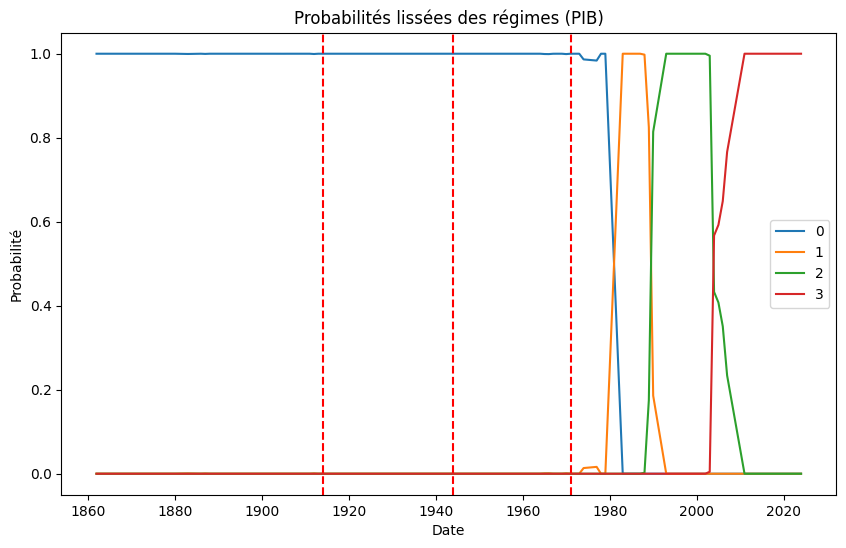

In [61]:
### MARKOV POUR LE PIB 
markov_pib = MarkovRegression(y, k_regimes = nreg, exog = i_gdp, switching_variance = True)

# Estimationd du MLE
result_pib = markov_pib.fit()
print(result_pib.summary())

# # Matrice de transition
#print(result_pib.model.transition_matrix)

# Probbailités smoothés
probs = result_pib.smoothed_marginal_probabilities

print(f"Année de transition gold standard -> Bretton Wood : {probs.index[probs[0] < probs[1]].min()}")
print(f"Année de transition Bretton Wood -> Floating Rate : {probs.index[(probs.index > 1900.0) & (probs[1] < probs[2])].min()}")

#Plot des résultats des probabilités lissés
probs.plot(figsize=(10,6))
plt.title("Probabilités lissées des régimes (PIB)")
plt.xlabel("Date")
plt.axvline(x=1914, color='red', linestyle='--', label='Seuil')
plt.axvline(x=1944, color='red', linestyle='--', label='Seuil')
plt.axvline(x=1971, color='red', linestyle='--', label='Seuil')
plt.ylabel("Probabilité")
plt.show()

/Users/timeogrienti/economic_research/venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Users/timeogrienti/economic_research/venv/lib/python3.14/site-packages/statsmodels/tsa/regime_switching/markov_switching.py:1292: EstimationWarning: Invalid regime transition probabilities estimated in EM iteration; probabilities have been re-scaled to continue estimation.
  warnings.warn('Invalid regime transition probabilities'
/Users/timeogrienti/economic_research/venv/lib/python3.14/site-packages/statsmodels/tsa/regime_switching/markov_switching.py:1292: EstimationWarning: Invalid regime transition probabilities estimated in EM iteration; probabilities have been re-scaled to continue estimation.
  warnings.warn('Invalid regime transition probabilities'
/Users/timeogrienti/e

Année de transition gold standard -> Bretton Wood : 1983.0
Année de transition Bretton Wood -> Floating Rate : 1913.0


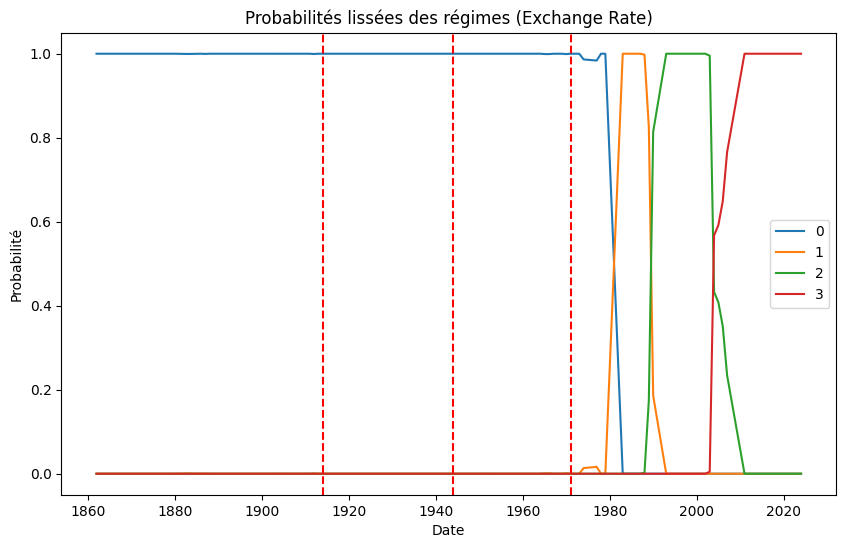

In [62]:
### MRKOV POUR LE TAUX DE CHANGE
markov_change = MarkovRegression(e, k_regimes = nreg, exog = i_exch, switching_variance = True)

# Estimationd du MLE
result_change = markov_pib.fit()
# print(result_change.summary())

# # Matrice de transition
# print(result_change.transition_matrix)

# Probbailités smoothés
probs_change = result_change.smoothed_marginal_probabilities

print(f"Année de transition gold standard -> Bretton Wood : {probs_change.index[probs_change[0] < probs_change[1]].min()}")
print(f"Année de transition Bretton Wood -> Floating Rate : {probs_change.index[(probs_change.index > 1900.0) & (probs_change[1] < probs_change[2])].min()}")

#Plot des résultats des probabilités lissés
probs_change.plot(figsize=(10,6))
plt.title("Probabilités lissées des régimes (Exchange Rate)")
plt.axvline(x=1914, color='red', linestyle='--', label='Seuil')
plt.axvline(x=1944, color='red', linestyle='--', label='Seuil')
plt.axvline(x=1971, color='red', linestyle='--', label='Seuil')
plt.xlabel("Date")
plt.ylabel("Probabilité")
plt.show()

/Users/timeogrienti/economic_research/venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Users/timeogrienti/economic_research/venv/lib/python3.14/site-packages/statsmodels/tsa/regime_switching/markov_switching.py:1292: EstimationWarning: Invalid regime transition probabilities estimated in EM iteration; probabilities have been re-scaled to continue estimation.
  warnings.warn('Invalid regime transition probabilities'
/Users/timeogrienti/economic_research/venv/lib/python3.14/site-packages/statsmodels/tsa/regime_switching/markov_switching.py:1292: EstimationWarning: Invalid regime transition probabilities estimated in EM iteration; probabilities have been re-scaled to continue estimation.
  warnings.warn('Invalid regime transition probabilities'
/Users/timeogrienti/e

Année de transition gold standard -> Bretton Wood : 1947.0
Année de transition Bretton Wood -> Floating Rate : 1983.0


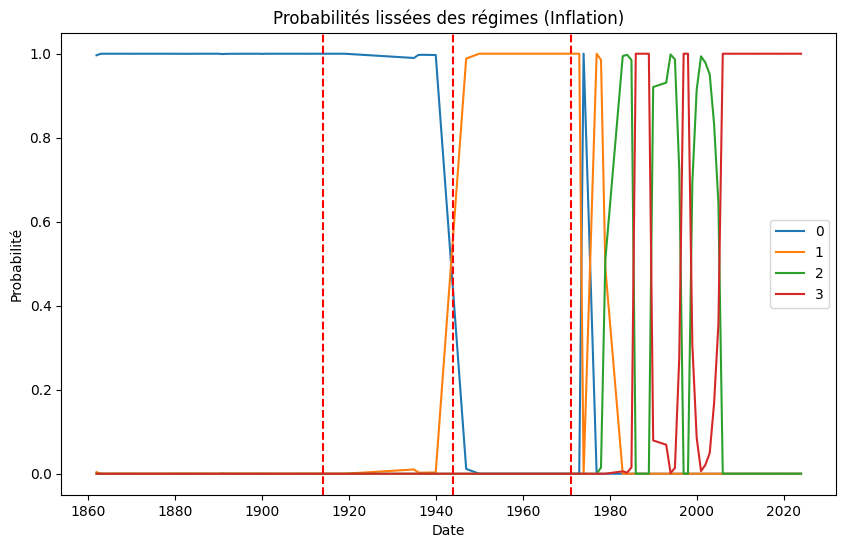

In [63]:
### MARKOV POUR L'INFLATION
markov_pi = MarkovRegression(pi, k_regimes = nreg, exog = i_inf, switching_variance = True)

# Estimationd du MLE
result_pi = markov_pi.fit()
# print(result_change.summary())

# # Matrice de transition
# print(result_change.transition_matrix)

# Probbailités smoothés
probs_pi = result_pi.smoothed_marginal_probabilities

print(f"Année de transition gold standard -> Bretton Wood : {probs_pi.index[probs_pi[0] < probs_pi[1]].min()}")
print(f"Année de transition Bretton Wood -> Floating Rate : {probs_pi.index[(probs_pi.index > 1980.0) & (probs_pi[1] < probs_pi[2])].min()}")

#Plot des résultats des probabilités lissés
probs_pi.plot(figsize=(10,6))
plt.title("Probabilités lissées des régimes (Inflation)")
plt.axvline(x=1914, color='red', linestyle='--', label='Seuil')
plt.axvline(x=1944, color='red', linestyle='--', label='Seuil')
plt.axvline(x=1971, color='red', linestyle='--', label='Seuil')
plt.xlabel("Date")
plt.ylabel("Probabilité")
plt.show()

## **MS-VAR : Markov Regime switching vectorial auto regressive model** 

In [64]:
data_R = data.set_index('year')  # inplace=True returns None, so remove it

y = data_R['gdp_nominal_stat']
e = data_R['taux_changes_stat']
pi = data_R['cpi_stat']
i = data_R['taux_directeur']

# one df
df = data_R[['gdp_nominal_stat', 'taux_changes_stat', 'cpi_stat', 'taux_directeur']]

KeyError: "None of ['year'] are in the columns"